# Avance 1 – Análisis Exploratorio de Datos (EDA)

## Contexto

El dataset de entrada es el panel mensual generado en `A0_Preprocesamiento.ipynb`.
Cada fila representa el **gasto total normalizado de un Centro Gestor en una Partida
Presupuestal en un mes**, expresado en tarifas vigentes del Periodo 3 (jun 2025–presente).

- **Unidad de observación del modelo:** Centro Gestor × Partida Presupuestal × Mes
- **Variable objetivo:** `Gasto_Normalizado` (pesos MXN, tarifas 2025)
- **Cobertura:** enero 2018 – abril 2026 (100 meses)

### Preguntas guía del EDA
1. ¿Cuál es la distribución del gasto mensual? ¿Está sesgada?
2. ¿Cuántos meses tienen gasto = $0? ¿Varía por partida?
3. ¿Existen patrones estacionales claros?
4. ¿Qué impacto tuvo COVID-19?
5. ¿Qué centros gestores concentran el gasto?
6. ¿Hay correlación entre partidas?
7. ¿Hay outliers que deban atenderse antes de modelar?


---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)

PALETTE = ['#1a5276','#2980b9','#85c1e9','#e74c3c','#e67e22',
           '#2ecc71','#8e44ad','#f39c12','#1abc9c','#c0392b']
sns.set_style('whitegrid')
sns.set_palette(PALETTE)

PARTIDAS_LABELS = {
    26102: '26102 – Gasolina Resto Personal',
    26104: '26104 – Gasolina Funcionarios',
    37101: '37101 – Avión Resto Personal',
    37104: '37104 – Avión Funcionarios',
    37201: '37201 – Transporte Terrestre Resto Personal',
    37204: '37204 – Transporte Terrestre Funcionarios',
    37501: '37501 – Viáticos Resto Personal',
    37504: '37504 – Viáticos Funcionarios',
}
print('OK')

OK


---
## 1. Carga del panel

In [2]:
panel = pd.read_parquet('panel_cg_partida_mes.parquet')

# Derivar variables de calendario para análisis
panel['Anio'] = panel['Anio_Mes'].dt.year
panel['Mes']  = panel['Anio_Mes'].dt.month

print(f'Filas totales            : {len(panel):,}')
print(f'Centros gestores         : {panel["Centro Gestor"].nunique()}')
print(f'Partidas presupuestales  : {panel["Partida Presupuestal"].nunique()}')
print(f'Combinaciones CG×Partida : {panel.groupby(["Centro Gestor","Partida Presupuestal"]).ngroups}')
print(f'Meses cubiertos          : {panel["Anio_Mes"].nunique()} ({panel["Anio_Mes"].min()} → {panel["Anio_Mes"].max()})')
print(f'\nGasto total histórico (normalizado): ${panel["Gasto_Normalizado"].sum():,.0f}')
panel.head(6)

Filas totales            : 27,200
Centros gestores         : 36
Partidas presupuestales  : 8
Combinaciones CG×Partida : 272
Meses cubiertos          : 100 (2018-01 → 2026-04)

Gasto total histórico (normalizado): $307,895,690


,Centro Gestor,Nombre Centro Gestor,Partida Presupuestal,Anio,Mes,Anio_Mes,Gasto_Normalizado,Gasto_Original,Num_Registros,Num_Viajes
0,10000000,Dirección General,26102,2018,1,2018-01,0.00,0.00,0,0
1,10000000,Dirección General,26102,2018,2,2018-02,580.10,580.10,1,1
2,10000000,Dirección General,26102,2018,3,2018-03,0.00,0.00,0,0
3,10000000,Dirección General,26102,2018,4,2018-04,0.00,0.00,0,0
4,10000000,Dirección General,26102,2018,5,2018-05,"1,160.35","1,160.35",2,2
5,10000000,Dirección General,26102,2018,6,2018-06,"1,220.53","1,220.53",1,1


---
## 2. Estructura del dataset

### Descripción de columnas


In [3]:
col_desc = {
    'Centro Gestor'        : 'Código de la unidad de presupuesto (36 unidades en FIRA)',
    'Nombre Centro Gestor' : 'Nombre legible de la unidad administrativa',
    'Partida Presupuestal' : 'Partida del clasificador por objeto del gasto (8 partidas)',
    'Anio'                 : 'Año de la fecha contable',
    'Mes'                  : 'Mes de la fecha contable (1=enero, 12=diciembre)',
    'Anio_Mes'             : 'Período año-mes (índice de la serie de tiempo)',
    'Gasto_Normalizado'    : 'VARIABLE OBJETIVO: gasto mensual en tarifas 2025 (MXN)',
    'Gasto_Original'       : 'Gasto mensual en moneda histórica nominal (referencia)',
    'Num_Registros'        : 'Cantidad de renglones SAP que integran el mes',
    'Num_Viajes'           : 'Cantidad de viajes distintos en el mes',
}
pd.DataFrame({'Columna': col_desc.keys(), 'Descripción': col_desc.values()})

,Columna,Descripción
0,Centro Gestor,Código de la unidad de presupuesto (36 unidade...
1,Nombre Centro Gestor,Nombre legible de la unidad administrativa
2,Partida Presupuestal,Partida del clasificador por objeto del gasto ...
3,Anio,Año de la fecha contable
4,Mes,"Mes de la fecha contable (1=enero, 12=diciembre)"
5,Anio_Mes,Período año-mes (índice de la serie de tiempo)
6,Gasto_Normalizado,VARIABLE OBJETIVO: gasto mensual en tarifas 20...
7,Gasto_Original,Gasto mensual en moneda histórica nominal (ref...
8,Num_Registros,Cantidad de renglones SAP que integran el mes
9,Num_Viajes,Cantidad de viajes distintos en el mes


In [4]:
print('Estadísticas descriptivas:')
panel[['Gasto_Normalizado','Gasto_Original','Num_Registros','Num_Viajes']].describe().T

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
Gasto_Normalizado,"27,200.00","11,319.69","50,532.72",0.00,0.00,0.00,"3,256.93","1,087,127.67"
Gasto_Original,"27,200.00","10,028.68","43,444.87",0.00,0.00,0.00,"3,036.39","939,270.96"
Num_Registros,"27,200.00",18.45,103.41,0.00,0.00,0.00,3.00,"2,117.00"
Num_Viajes,"27,200.00",10.55,51.78,0.00,0.00,0.00,2.00,785.00


---
## 3. Distribución de la variable objetivo

### 3.1 El problema de los ceros

El 62.5% de las filas del panel tiene gasto = \$0.
Esto no es un dato faltante — significa que ese centro gestor
**no registró gasto** en esa partida ese mes. Es un patrón real y esperado:
no todos los centros gestores viajan en todas las partidas todos los meses.

Este alto porcentaje de ceros tiene implicaciones para el modelado:
modelos como regresión lineal simple asumirán que siempre hay gasto positivo.
Se deberá considerar un modelo que maneje bien la masa de ceros
(Tweedie, modelo de dos etapas, o transformación apropiada).


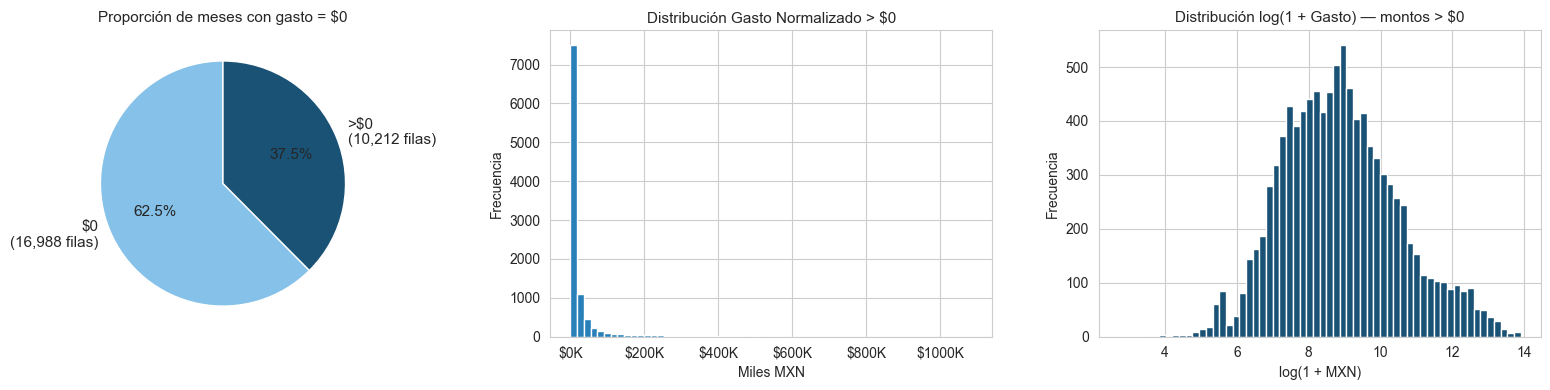

Skewness (montos > $0): 5.67  — distribución muy sesgada a la derecha
Mediana: $6,592   Media: $30,150   Máximo: $1,087,128

HALLAZGO: La distribución es fuertemente asimétrica (skew > 5).
La transformación log(1+x) la aproxima a una normal.
Se considerará esta transformación en Feature Engineering (A2).


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gráfica 1: proporción de ceros vs. positivos
ceros    = (panel['Gasto_Normalizado'] == 0).sum()
positivos = (panel['Gasto_Normalizado'] > 0).sum()
axes[0].pie([ceros, positivos],
            labels=[f'$0\n({ceros:,} filas)', f'>$0\n({positivos:,} filas)'],
            colors=['#85c1e9','#1a5276'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Proporción de meses con gasto = $0', fontsize=11)

# Gráfica 2: distribución del gasto > 0
no_cero = panel[panel['Gasto_Normalizado'] > 0]['Gasto_Normalizado']
axes[1].hist(no_cero / 1e3, bins=60, color='#2980b9', edgecolor='white')
axes[1].set_title('Distribución Gasto Normalizado > $0', fontsize=11)
axes[1].set_xlabel('Miles MXN')
axes[1].set_ylabel('Frecuencia')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# Gráfica 3: distribución en escala logarítmica
axes[2].hist(np.log1p(no_cero), bins=60, color='#1a5276', edgecolor='white')
axes[2].set_title('Distribución log(1 + Gasto) — montos > $0', fontsize=11)
axes[2].set_xlabel('log(1 + MXN)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'Skewness (montos > $0): {no_cero.skew():.2f}  — distribución muy sesgada a la derecha')
print(f'Mediana: ${no_cero.median():,.0f}   Media: ${no_cero.mean():,.0f}   Máximo: ${no_cero.max():,.0f}')
print('\nHALLAZGO: La distribución es fuertemente asimétrica (skew > 5).')
print('La transformación log(1+x) la aproxima a una normal.')
print('Se considerará esta transformación en Feature Engineering (A2).')

### 3.2 Porcentaje de ceros por partida

Las partidas de avión (371xx) tienen ~89% de ceros — la mayoría de centros gestores
no registra vuelos. Las partidas de viáticos (375xx) y transporte terrestre (372xx)
tienen menor proporción de ceros, lo que sugiere mayor actividad regular.


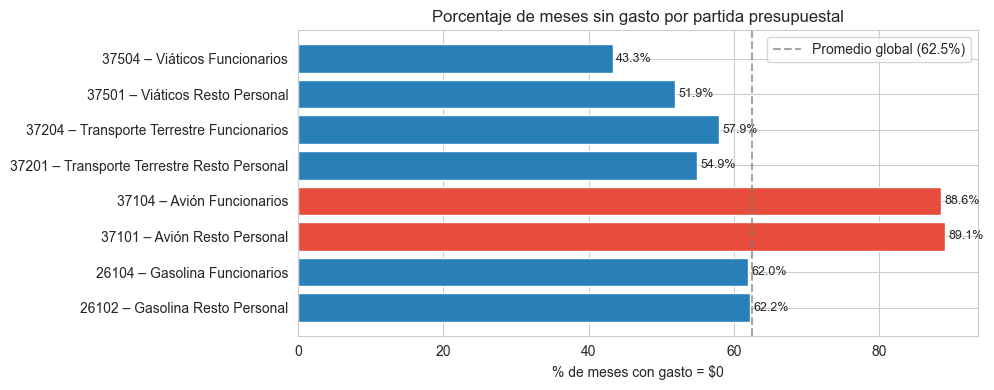

HALLAZGO: Las partidas 371xx (avión) tienen ~89% de ceros.
Son partidas especiales: solo ciertos CGs tienen viajes con transportación aérea.
Se modelarán por separado o se aplicará un modelo de dos etapas.


In [6]:
pct_cero = (panel.groupby('Partida Presupuestal')
             .apply(lambda x: (x['Gasto_Normalizado']==0).mean()*100)
             .rename('% de ceros')
             .reset_index())
pct_cero['Partida'] = pct_cero['Partida Presupuestal'].map(PARTIDAS_LABELS)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(pct_cero['Partida'], pct_cero['% de ceros'],
               color=['#e74c3c' if v > 80 else '#2980b9' for v in pct_cero['% de ceros']],
               edgecolor='white')
ax.set_xlabel('% de meses con gasto = $0')
ax.set_title('Porcentaje de meses sin gasto por partida presupuestal', fontsize=12)
ax.axvline(62.5, color='gray', linestyle='--', alpha=0.7, label='Promedio global (62.5%)')
ax.legend()
for bar, v in zip(bars, pct_cero['% de ceros']):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('HALLAZGO: Las partidas 371xx (avión) tienen ~89% de ceros.')
print('Son partidas especiales: solo ciertos CGs tienen viajes con transportación aérea.')
print('Se modelarán por separado o se aplicará un modelo de dos etapas.')

---
## 4. Análisis temporal

### 4.1 Gasto mensual total — serie de tiempo


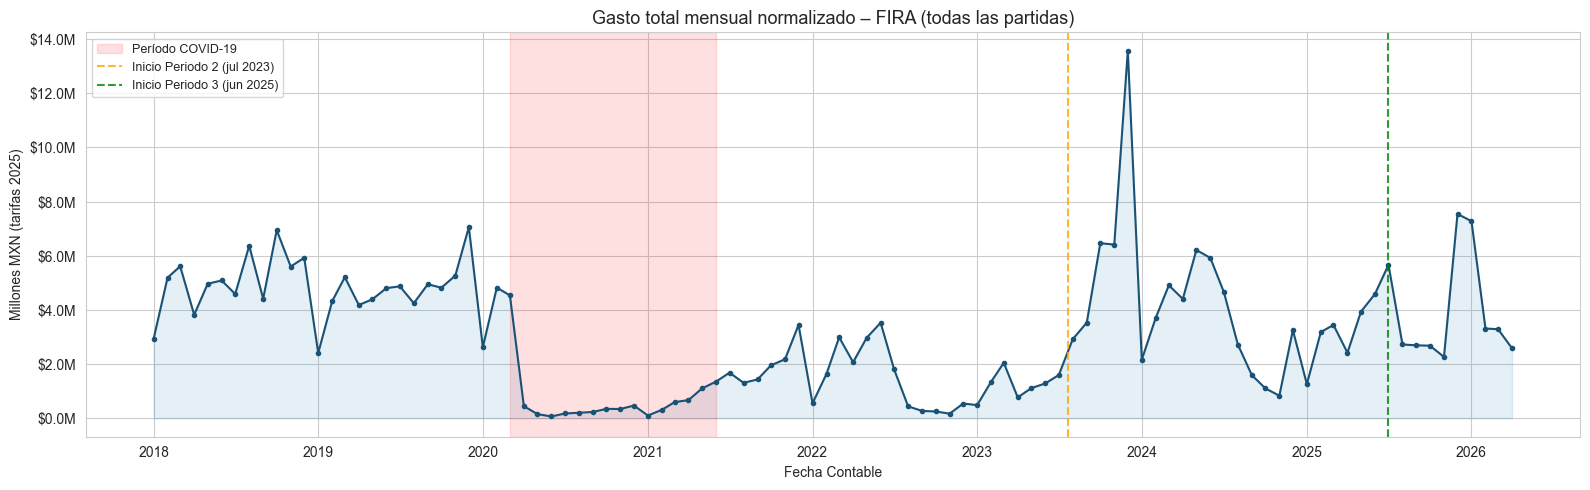

Gasto total normalizado por año:
  2018: $  61.5M  
  2019: $  56.6M  
  2020: $  14.5M  ← COVID
  2021: $  16.2M  ← COVID
  2022: $  17.3M  
  2023: $  41.6M  
  2024: $  41.5M  
  2025: $  42.4M  
  2026: $  16.5M  ← incompleto

HALLAZGO: COVID-19 provocó una caída del 74.4% en 2020 respecto a 2019.
Los años 2020-2021 son atípicos y se deberán tratar con cuidado en el modelado.


In [7]:
gasto_mes = panel.groupby('Anio_Mes')['Gasto_Normalizado'].sum().reset_index()
gasto_mes['fecha'] = gasto_mes['Anio_Mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(gasto_mes['fecha'], gasto_mes['Gasto_Normalizado']/1e6,
        color='#1a5276', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(gasto_mes['fecha'], gasto_mes['Gasto_Normalizado']/1e6,
                alpha=0.12, color='#2980b9')

# Marcadores de eventos clave
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.12, color='red', label='Período COVID-19')
ax.axvline(pd.Timestamp('2023-07-21'), color='orange', linestyle='--',
           alpha=0.8, linewidth=1.5, label='Inicio Periodo 2 (jul 2023)')
ax.axvline(pd.Timestamp('2025-06-30'), color='green', linestyle='--',
           alpha=0.8, linewidth=1.5, label='Inicio Periodo 3 (jun 2025)')

ax.set_title('Gasto total mensual normalizado – FIRA (todas las partidas)', fontsize=13)
ax.set_xlabel('Fecha Contable')
ax.set_ylabel('Millones MXN (tarifas 2025)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Gasto anual
gasto_anual = panel.groupby('Anio')['Gasto_Normalizado'].sum()
print('Gasto total normalizado por año:')
for anio, g in gasto_anual.items():
    flag = '← COVID' if anio in [2020,2021] else ('← incompleto' if anio==2026 else '')
    print(f'  {anio}: ${g/1e6:>6.1f}M  {flag}')
print(f'\nHALLAZGO: COVID-19 provocó una caída del 74.4% en 2020 respecto a 2019.')
print('Los años 2020-2021 son atípicos y se deberán tratar con cuidado en el modelado.')

### 4.2 Gasto mensual por partida presupuestal

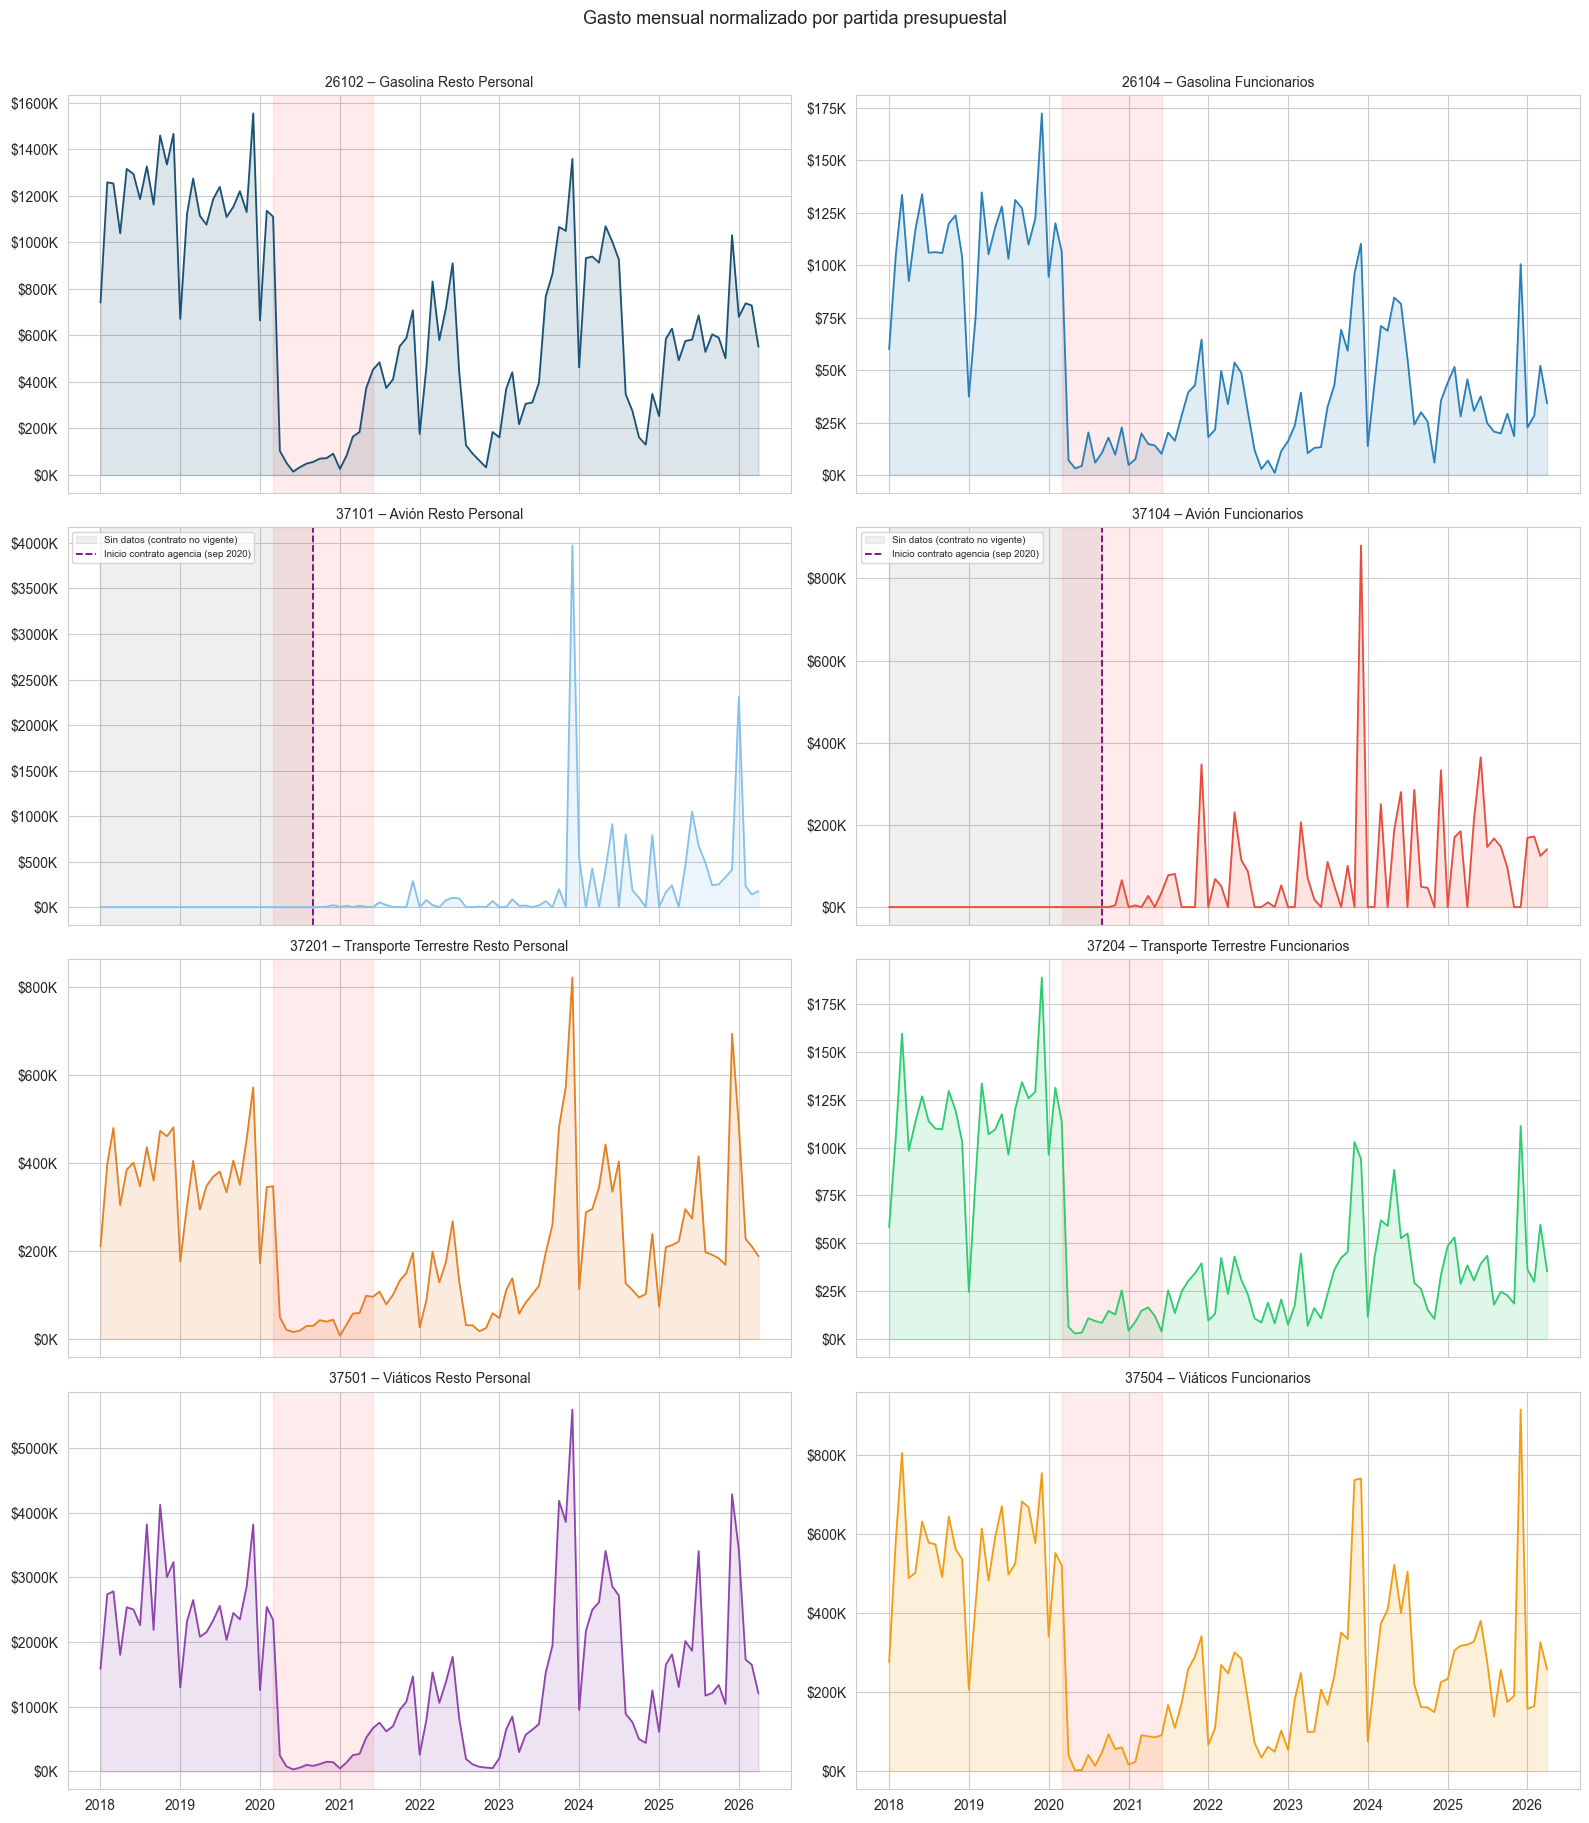

NOTA — Partidas 371xx (avión):
  Los ceros previos a septiembre 2020 no indican falta de viajes en avión,
  sino que el contrato con la agencia externa aún no estaba vigente.
  El histórico válido para modelar estas partidas inicia en sep-2020.


In [8]:
gasto_partida_mes = (panel.groupby(['Anio_Mes','Partida Presupuestal'])
                       ['Gasto_Normalizado'].sum().reset_index())
gasto_partida_mes['fecha'] = gasto_partida_mes['Anio_Mes'].dt.to_timestamp()

partidas = sorted(panel['Partida Presupuestal'].unique())
fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

INICIO_AVION = pd.Timestamp('2020-09-01')

for i, partida in enumerate(partidas):
    data = gasto_partida_mes[gasto_partida_mes['Partida Presupuestal']==partida]
    axes[i].plot(data['fecha'], data['Gasto_Normalizado']/1e3,
                 color=PALETTE[i], linewidth=1.3)
    axes[i].fill_between(data['fecha'], data['Gasto_Normalizado']/1e3,
                          alpha=0.15, color=PALETTE[i])
    axes[i].set_title(PARTIDAS_LABELS[partida], fontsize=10)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
    axes[i].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
                    alpha=0.08, color='red')

    # Partidas de avión: marcar inicio del contrato y sombrear período sin datos
    if partida in [37101, 37104]:
        axes[i].axvspan(data['fecha'].min(), INICIO_AVION,
                        alpha=0.12, color='gray',
                        label='Sin datos (contrato no vigente)')
        axes[i].axvline(INICIO_AVION, color='purple', linestyle='--',
                        linewidth=1.3, label='Inicio contrato agencia (sep 2020)')
        axes[i].legend(fontsize=7, loc='upper left')

plt.suptitle('Gasto mensual normalizado por partida presupuestal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('NOTA — Partidas 371xx (avión):')
print('  Los ceros previos a septiembre 2020 no indican falta de viajes en avión,')
print('  sino que el contrato con la agencia externa aún no estaba vigente.')
print('  El histórico válido para modelar estas partidas inicia en sep-2020.')

### 4.3 Estacionalidad mensual

Se excluyen 2020 y 2021 (COVID) y 2026 (año incompleto) para el análisis estacional.


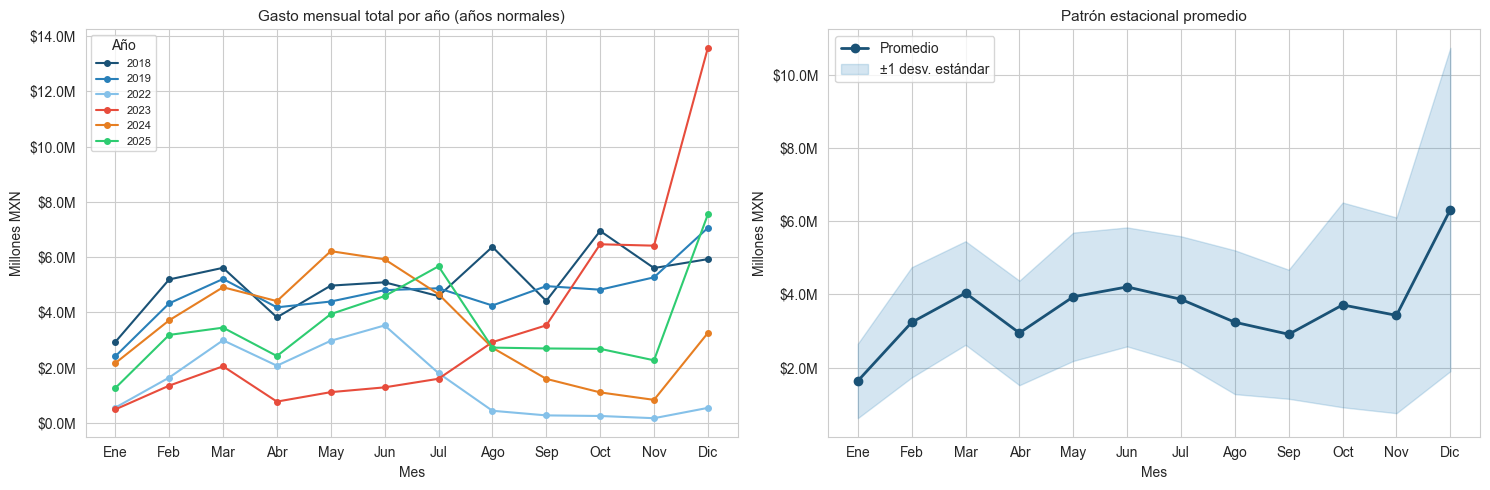

Mes de mayor gasto: Dic (promedio $6.3M)
Mes de menor gasto: Ene (promedio $1.6M)

HALLAZGO: Diciembre es el mes de mayor gasto (+94% sobre el promedio anual).
Enero es el mes de menor gasto, probablemente por el arranque del año fiscal.
La estacionalidad es consistente entre años — señal útil para el modelo.


In [9]:
AÑOS_NORMALES = [2018, 2019, 2022, 2023, 2024, 2025]
MESES_LABELS  = ['Ene','Feb','Mar','Abr','May','Jun',
                  'Jul','Ago','Sep','Oct','Nov','Dic']

estac = (panel[panel['Anio'].isin(AÑOS_NORMALES)]
         .groupby(['Anio','Mes'])['Gasto_Normalizado']
         .sum()
         .reset_index())
pivot = estac.pivot(index='Mes', columns='Anio', values='Gasto_Normalizado')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Líneas por año
for anio in pivot.columns:
    axes[0].plot(pivot.index, pivot[anio]/1e6, marker='o',
                 label=str(anio), linewidth=1.5, markersize=4)
axes[0].set_title('Gasto mensual total por año (años normales)', fontsize=11)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Millones MXN')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(MESES_LABELS)
axes[0].legend(title='Año', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# Promedio ± desviación
media = pivot.mean(axis=1)
std   = pivot.std(axis=1)
axes[1].plot(pivot.index, media/1e6, color='#1a5276', linewidth=2,
             marker='o', label='Promedio')
axes[1].fill_between(pivot.index, (media-std)/1e6, (media+std)/1e6,
                      alpha=0.2, color='#2980b9', label='±1 desv. estándar')
axes[1].set_title('Patrón estacional promedio', fontsize=11)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Millones MXN')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(MESES_LABELS)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

plt.tight_layout()
plt.show()

mes_max = media.idxmax()
mes_min = media.idxmin()
print(f'Mes de mayor gasto: {MESES_LABELS[mes_max-1]} (promedio ${media[mes_max]/1e6:.1f}M)')
print(f'Mes de menor gasto: {MESES_LABELS[mes_min-1]} (promedio ${media[mes_min]/1e6:.1f}M)')
print('\nHALLAZGO: Diciembre es el mes de mayor gasto (+94% sobre el promedio anual).')
print('Enero es el mes de menor gasto, probablemente por el arranque del año fiscal.')
print('La estacionalidad es consistente entre años — señal útil para el modelo.')

---
## 5. Distribución por Centro Gestor

### 5.1 Concentración del gasto


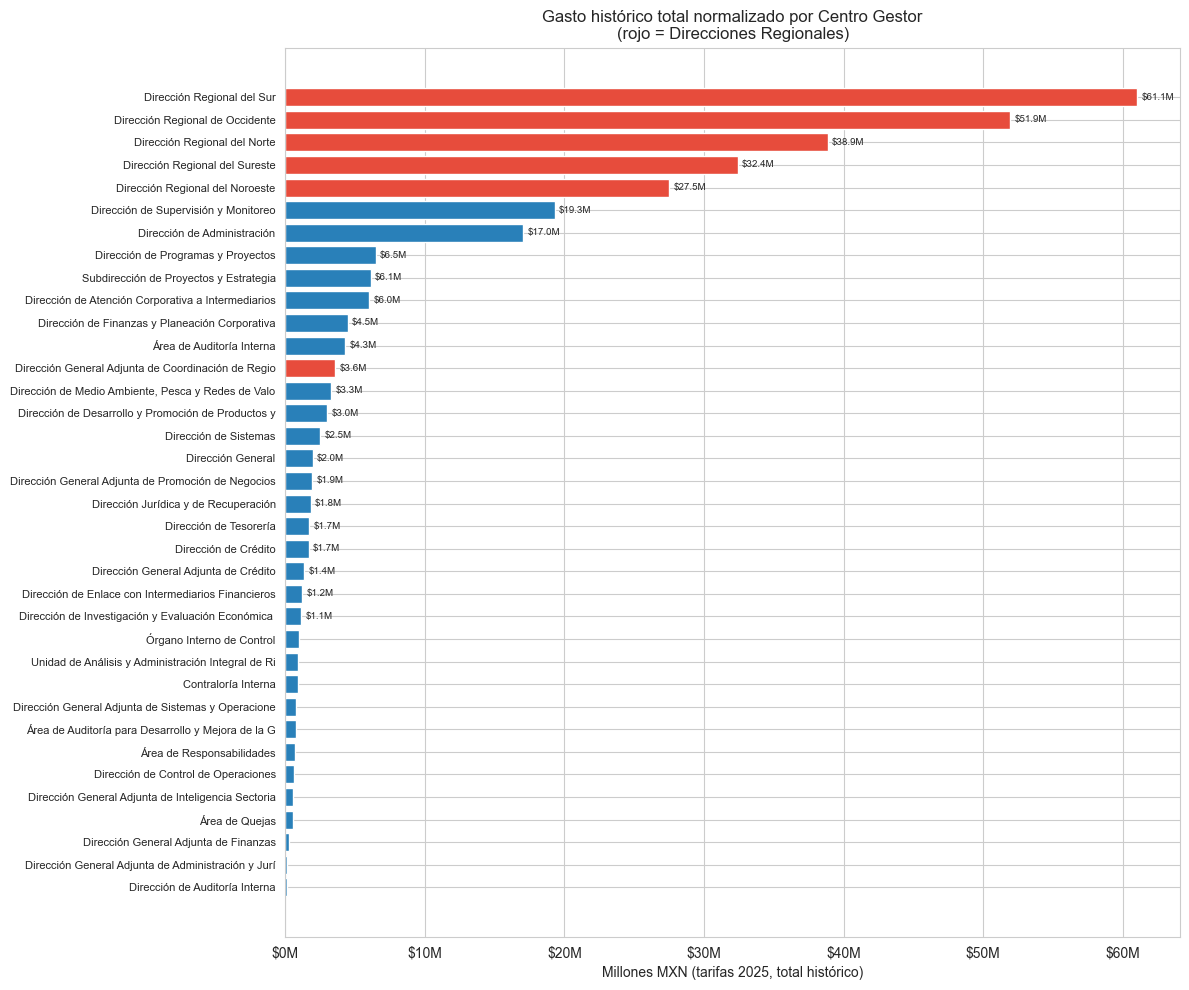

Top 5 CGs concentran: 68.8% del gasto total
Direcciones Regionales concentran: 69.9% del gasto total

HALLAZGO: Las 5 Direcciones Regionales concentran la mayor parte del gasto.
Son las unidades con mayor actividad de campo (visitas a acreditados, supervisión).


In [10]:
gasto_cg = (panel.groupby('Nombre Centro Gestor')['Gasto_Normalizado']
              .sum().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#e74c3c' if 'Regional' in n else '#2980b9' for n in gasto_cg.index]
bars = ax.barh(range(len(gasto_cg)), gasto_cg.values/1e6, color=colors, edgecolor='white')
ax.set_yticks(range(len(gasto_cg)))
ax.set_yticklabels([n[:50] for n in gasto_cg.index], fontsize=8)
ax.set_xlabel('Millones MXN (tarifas 2025, total histórico)')
ax.set_title('Gasto histórico total normalizado por Centro Gestor\n(rojo = Direcciones Regionales)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
for bar, v in zip(bars, gasto_cg.values):
    if v > 1e6:
        ax.text(v/1e6 + 0.3, bar.get_y() + bar.get_height()/2,
                f'${v/1e6:.1f}M', va='center', fontsize=7)
plt.tight_layout()
plt.show()

# Concentración
top5_pct = gasto_cg.nlargest(5).sum() / gasto_cg.sum() * 100
regionales_pct = gasto_cg[gasto_cg.index.str.contains('Regional')].sum() / gasto_cg.sum() * 100
print(f'Top 5 CGs concentran: {top5_pct:.1f}% del gasto total')
print(f'Direcciones Regionales concentran: {regionales_pct:.1f}% del gasto total')
print('\nHALLAZGO: Las 5 Direcciones Regionales concentran la mayor parte del gasto.')
print('Son las unidades con mayor actividad de campo (visitas a acreditados, supervisión).')

### 5.2 Distribución por Centro Gestor y Partida

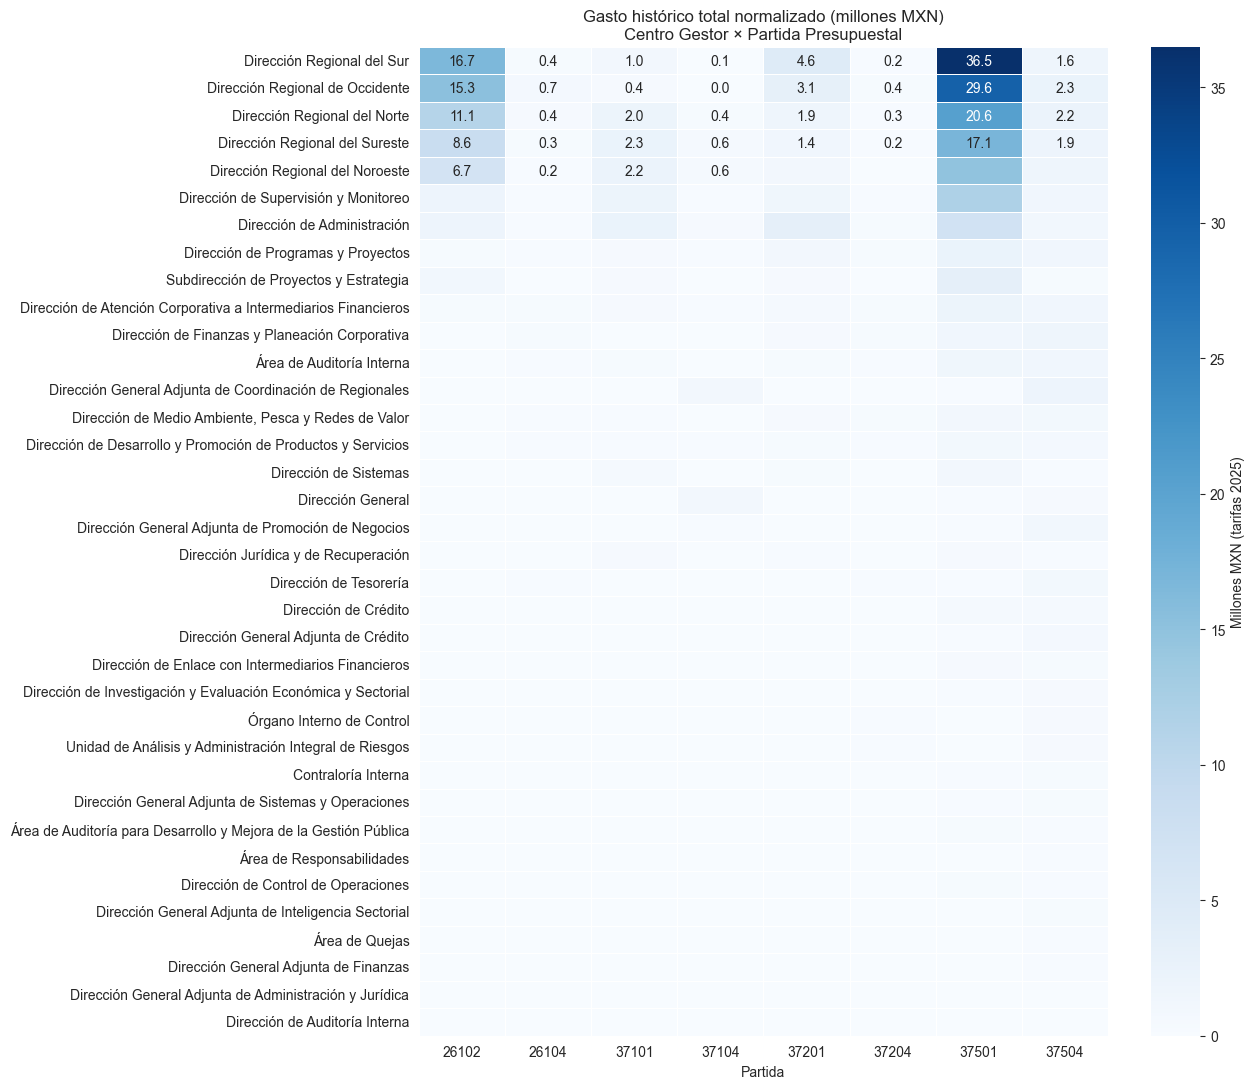

HALLAZGO: La partida 37501 (Viáticos Resto Personal) domina en todas las
Direcciones Regionales. Las partidas 371xx (avión) muestran gasto casi nulo
en la mayoría de centros gestores — confirma su comportamiento atípico.


In [11]:
pivot_cg = (panel.groupby(['Nombre Centro Gestor','Partida Presupuestal'])
              ['Gasto_Normalizado'].sum()
              .unstack(fill_value=0))
pivot_cg.columns = [PARTIDAS_LABELS[c].split('–')[0].strip() for c in pivot_cg.columns]
pivot_cg = pivot_cg.loc[pivot_cg.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(pivot_cg/1e6, annot=True, fmt='.1f', cmap='Blues',
            ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Millones MXN (tarifas 2025)'})
ax.set_title('Gasto histórico total normalizado (millones MXN)\nCentro Gestor × Partida Presupuestal', fontsize=12)
ax.set_xlabel('Partida')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('HALLAZGO: La partida 37501 (Viáticos Resto Personal) domina en todas las')
print('Direcciones Regionales. Las partidas 371xx (avión) muestran gasto casi nulo')
print('en la mayoría de centros gestores — confirma su comportamiento atípico.')

---
## 6. Análisis de outliers

Se analiza únicamente sobre filas con gasto > $0 (los ceros son estructurales).


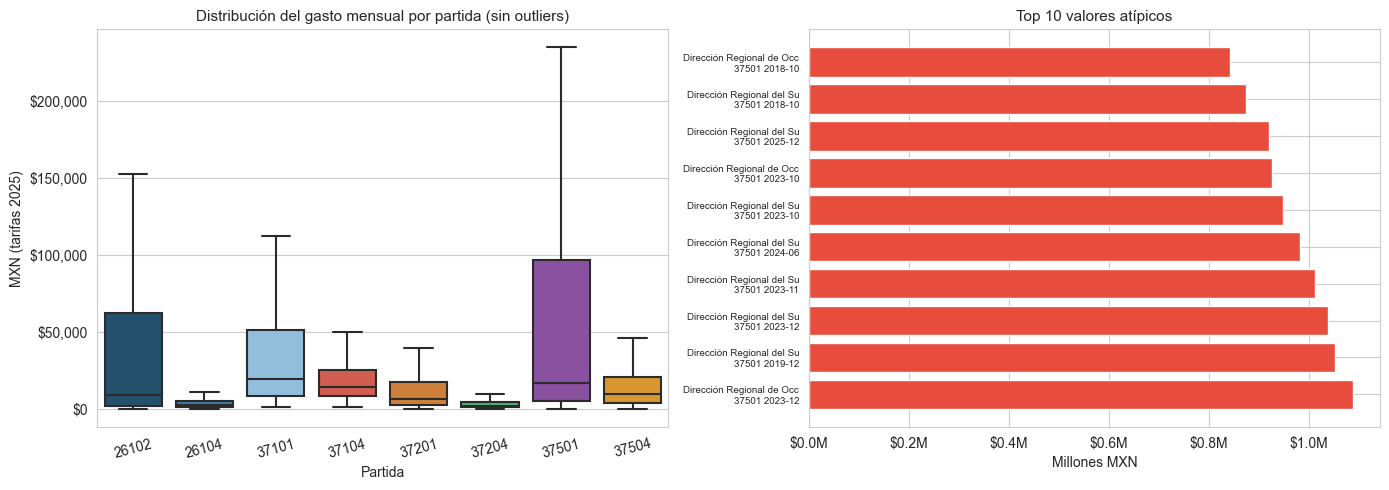

Límite IQR superior: $46,165
Outliers (gasto > límite): 1,304 (12.8% de filas con gasto > $0)

HALLAZGO: Los outliers corresponden a meses de alta actividad en Direcciones
Regionales — son valores plausibles de negocio, no errores de datos.
Se tratarán con transformación log o winsorización en Feature Engineering.


In [12]:
no_cero = panel[panel['Gasto_Normalizado'] > 0].copy()

Q1  = no_cero['Gasto_Normalizado'].quantile(0.25)
Q3  = no_cero['Gasto_Normalizado'].quantile(0.75)
IQR = Q3 - Q1
lim = Q3 + 1.5 * IQR

outliers = no_cero[no_cero['Gasto_Normalizado'] > lim]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por partida
no_cero_plot = no_cero.copy()
no_cero_plot['Partida'] = no_cero_plot['Partida Presupuestal'].astype(str)
sns.boxplot(data=no_cero_plot, x='Partida', y='Gasto_Normalizado',
            order=[str(p) for p in sorted(panel['Partida Presupuestal'].unique())],
            palette=PALETTE, showfliers=False, ax=axes[0])
axes[0].set_title('Distribución del gasto mensual por partida (sin outliers)', fontsize=11)
axes[0].set_ylabel('MXN (tarifas 2025)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

# Top outliers
top_out = (outliers.nlargest(10, 'Gasto_Normalizado')
           [['Nombre Centro Gestor','Partida Presupuestal','Anio_Mes','Gasto_Normalizado']])
axes[1].barh(range(len(top_out)),
             top_out['Gasto_Normalizado'].values/1e6,
             color='#e74c3c', edgecolor='white')
labels = [f"{r['Nombre Centro Gestor'][:25]}\n{r['Partida Presupuestal']} {r['Anio_Mes']}"
          for _, r in top_out.iterrows()]
axes[1].set_yticks(range(len(top_out)))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel('Millones MXN')
axes[1].set_title('Top 10 valores atípicos', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

plt.tight_layout()
plt.show()

print(f'Límite IQR superior: ${lim:,.0f}')
print(f'Outliers (gasto > límite): {len(outliers):,} ({len(outliers)/len(no_cero)*100:.1f}% de filas con gasto > $0)')
print('\nHALLAZGO: Los outliers corresponden a meses de alta actividad en Direcciones')
print('Regionales — son valores plausibles de negocio, no errores de datos.')
print('Se tratarán con transformación log o winsorización en Feature Engineering.')

---
## 7. Correlación entre partidas

Se analiza la correlación entre el gasto mensual agregado de las 8 partidas.


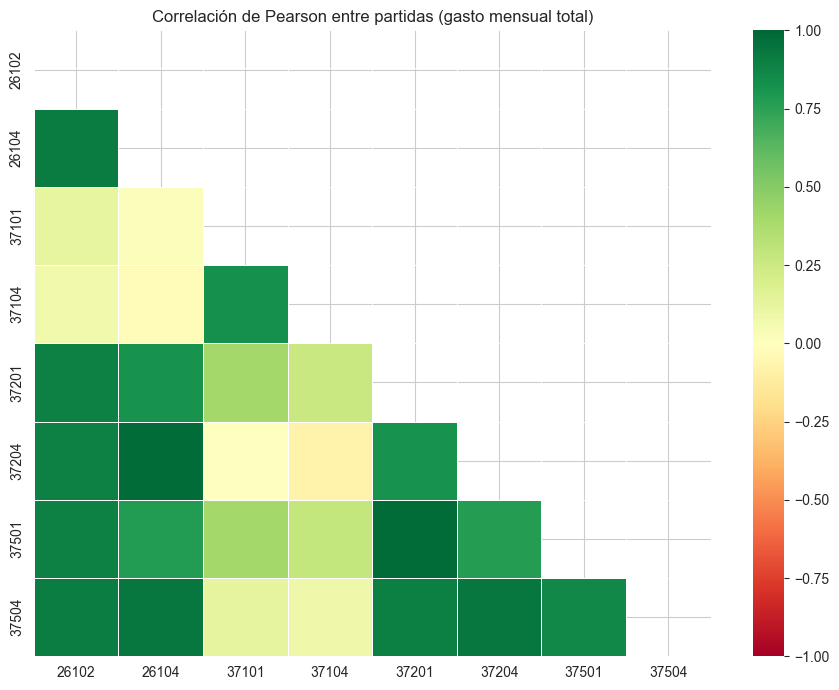

HALLAZGO: Las partidas de viáticos (375xx), gasolina (261xx) y transporte
terrestre (372xx) están altamente correlacionadas (r > 0.80) — tienen el
mismo patrón de actividad de campo.
Las partidas de avión (371xx) tienen correlación baja con el resto,
confirmando su comportamiento independiente y más esporádico.


In [13]:
pivot_corr = (panel.groupby(['Anio_Mes','Partida Presupuestal'])
               ['Gasto_Normalizado'].sum()
               .unstack(fill_value=0))
pivot_corr.columns = [PARTIDAS_LABELS[c].split('–')[0].strip() for c in pivot_corr.columns]
corr = pivot_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, mask=mask,
            ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Correlación de Pearson entre partidas (gasto mensual total)', fontsize=12)
plt.tight_layout()
plt.show()

print('HALLAZGO: Las partidas de viáticos (375xx), gasolina (261xx) y transporte')
print('terrestre (372xx) están altamente correlacionadas (r > 0.80) — tienen el')
print('mismo patrón de actividad de campo.')
print('Las partidas de avión (371xx) tienen correlación baja con el resto,')
print('confirmando su comportamiento independiente y más esporádico.')

---
## 8. Conclusiones del EDA

### Hallazgos principales

| # | Hallazgo | Implicación para el modelo |
|---|---|---|
| 1 | **62.5% de ceros** en el panel | Modelos que asuman gasto continuo no son adecuados. Considerar modelo de dos etapas o distribución Tweedie |
| 2 | **Distribución muy sesgada** (skew > 5) | Transformación log(1+x) para normalizar antes de entrenar |
| 3 | **Fuerte estacionalidad** — diciembre es el mes de mayor gasto | Incluir variables de calendario: mes, trimestre, indicador diciembre |
| 4 | **COVID-19** causó caída del 74.4% en 2020 | Los años 2020-2021 son atípicos; se evaluará si incluirlos o excluirlos del entrenamiento |
| 5 | **Partidas 371xx (avión)** con 89% de ceros, baja correlación con el resto, y datos disponibles **únicamente desde septiembre 2020** (inicio del contrato con agencia externa) | Modelar por separado; usar solo el histórico sep-2020 en adelante para estas partidas |
| 6 | **Direcciones Regionales** concentran la mayor parte del gasto | Variables de tipo de CG (regional vs. central) pueden mejorar el modelo |
| 7 | **Outliers plausibles** — no son errores | Se tratarán con winsorización o transformación log, no se eliminarán |

### Próximos pasos (A2 — Feature Engineering)

- Crear **variables de lag**: `t-1`, `t-2`, `t-3`, `t-12`
- Crear **medias móviles**: promedio de los últimos 3 y 6 meses
- Crear **variables de calendario**: mes, trimestre, indicador de diciembre, indicador de año COVID
- Aplicar **transformación log(1+x)** a `Gasto_Normalizado`
- Crear variable binaria `hubo_gasto` para el modelo de dos etapas
- Agregar variable de **tipo de CG** (regional / central)


In [14]:
print("""
=============================================================================
RESUMEN EDA — Avance 1
=============================================================================

Dataset: 27,200 filas | 36 centros gestores | 8 partidas | 100 meses

CALIDAD DE DATOS
  Sin valores faltantes en el panel final.
  62.5% de filas con gasto = $0 (estructural, no error).
  Distribución del gasto positivo: skew = 5.67 (muy asimétrica a la derecha).

PATRONES TEMPORALES
  Diciembre: mes de mayor gasto (promedio +94% sobre la media anual).
  Enero: mes de menor gasto (arranque de año fiscal).
  COVID-19 (2020-2021): caída del 74.4% en 2020 — años atípicos.

ESTRUCTURA DEL GASTO
  Partidas 375xx (viáticos): 56% del gasto total histórico.
  Partidas 261xx (gasolina): 23% del gasto total.
  Partidas 371xx (avión): comportamiento atípico, 89% de ceros.
  Direcciones Regionales: ~70% del gasto total.

IMPLICACIONES PARA EL MODELO
  → Distribución Tweedie o modelo de dos etapas para manejar ceros.
  → Transformación log(1+x) para la variable objetivo.
  → Variables de lag y estacionalidad como features principales.
  → Partidas 371xx posiblemente requieren modelo separado.
=============================================================================""")



RESUMEN EDA — Avance 1

Dataset: 27,200 filas | 36 centros gestores | 8 partidas | 100 meses

CALIDAD DE DATOS
  Sin valores faltantes en el panel final.
  62.5% de filas con gasto = $0 (estructural, no error).
  Distribución del gasto positivo: skew = 5.67 (muy asimétrica a la derecha).

PATRONES TEMPORALES
  Diciembre: mes de mayor gasto (promedio +94% sobre la media anual).
  Enero: mes de menor gasto (arranque de año fiscal).
  COVID-19 (2020-2021): caída del 74.4% en 2020 — años atípicos.

ESTRUCTURA DEL GASTO
  Partidas 375xx (viáticos): 56% del gasto total histórico.
  Partidas 261xx (gasolina): 23% del gasto total.
  Partidas 371xx (avión): comportamiento atípico, 89% de ceros.
  Direcciones Regionales: ~70% del gasto total.

IMPLICACIONES PARA EL MODELO
  → Distribución Tweedie o modelo de dos etapas para manejar ceros.
  → Transformación log(1+x) para la variable objetivo.
  → Variables de lag y estacionalidad como features principales.
  → Partidas 371xx posiblemente requie

---
## Referencias
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly. Caps. 2, 3.
- Visengeriyeva et al. (2023). *CRISP-ML(Q)*. MLOps/INNOQ. https://ml-ops.org/content/crisp-ml
- Avance 0 – Preprocesamiento. TC5035 Equipo 35. Mayo 2026.
